# <font color = "orange" > Project : Used car price prediction </font>

### 🚗 <font color="red"> Problem Statement </font>

The used car market generates a vast volume of vehicle listings daily, each varying widely in price based on numerous factors such as mileage, horsepower, engine specifications, brand, body type, and vehicle age.
For buyers, sellers, and dealerships, accurately estimating a fair market price is a persistent challenge — pricing decisions are often based on intuition, limited comparisons, or inconsistent market data, leading to overpricing, underpricing, or prolonged listing times.

The used car market generates a vast volume of vehicle listings daily,  
each varying widely in price based on numerous factors such as:

🛣️ Mileage  
⚙️ Horsepower & Engine Specifications  
🏷️ Brand & Model  
🚙 Body Type  
📅 Vehicle Age  

### <font color ="yellow">Please Download Dataset by Using Below link </font>
Dataset Link : https://drive.google.com/file/d/1Vjf87gmMC_eFApGOU9G9cfVrPbdFS9EE/view?usp=sharing

In [2]:
# Import core libraries for data handling, visualization, preprocessing, modeling, and evaluation
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import sklearn 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import LabelEncoder , MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb

In [3]:
# Load the raw used-car dataset from CSV into a DataFrame
df1 = pd.read_csv(r"D:\Inno Batch 485\Machine Learning\ML Projects\Used Car  Price Prediction\Data Set\used_car_dataset_dp.csv")

In [4]:
# Inspect column names, dtypes, and non-null counts
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   vin                      1000000 non-null  str    
 1   body_type                995631 non-null   str    
 2   combine_fuel_economy     0 non-null        float64
 3   combine_fuel_economy.1   0 non-null        float64
 4   engine_type              970830 non-null   str    
 5   fuel_type                975236 non-null   str    
 6   fuel_tank_volume         951854 non-null   str    
 7   is_new                   1000000 non-null  bool   
 8   maximum_seating          951854 non-null   str    
 9   mileage                  949369 non-null   float64
 10  model_name               1000000 non-null  str    
 11  power                    848943 non-null   str    
 12  price                    1000000 non-null  float64
 13  torque                   836789 non-null   str    
 14

In [5]:
# Preview the first 5 rows of the raw data
df1.head()

,vin,body_type,combine_fuel_economy,combine_fuel_economy.1,engine_type,fuel_type,fuel_tank_volume,is_new,maximum_seating,mileage,model_name,power,price,torque,transmission,vehicle_damage_category,wheel_system,wheel_system_display,wheelbase,year
0,ZACNJABB5KPJ92081,SUV / Crossover,NaN,NaN,I4,Gasoline,12.7 gal,True,5 seats,7.0,Renegade,"177 hp @ 5,750 RPM",23141.0,"200 lb-ft @ 1,750 RPM",A,NaN,FWD,Front-Wheel Drive,101.2 in,2019
1,SALCJ2FX1LH858117,SUV / Crossover,NaN,NaN,I4,Gasoline,17.7 gal,True,7 seats,8.0,Discovery Sport,"246 hp @ 5,500 RPM",46500.0,"269 lb-ft @ 1,400 RPM",A,NaN,AWD,All-Wheel Drive,107.9 in,2020
2,JF1VA2M67G9829723,Sedan,NaN,NaN,H4,Gasoline,15.9 gal,False,5 seats,NaN,WRX STI,"305 hp @ 6,000 RPM",46995.0,"290 lb-ft @ 4,000 RPM",M,NaN,AWD,All-Wheel Drive,104.3 in,2016
3,SALRR2RV0L2433391,SUV / Crossover,NaN,NaN,V6,Gasoline,23.5 gal,True,7 seats,11.0,Discovery,"340 hp @ 6,500 RPM",67430.0,"332 lb-ft @ 3,500 RPM",A,NaN,AWD,All-Wheel Drive,115 in,2020
4,SALCJ2FXXLH862327,SUV / Crossover,NaN,NaN,I4,Gasoline,17.7 gal,True,7 seats,7.0,Discovery Sport,"246 hp @ 5,500 RPM",48880.0,"269 lb-ft @ 1,400 RPM",A,NaN,AWD,All-Wheel Drive,107.9 in,2020


In [6]:
# Calculate the percentage of missing values per column
df1.isna().sum()/len(df1)*100

vin                          0.0000
body_type                    0.4369
combine_fuel_economy       100.0000
combine_fuel_economy.1     100.0000
engine_type                  2.9170
fuel_type                    2.4764
fuel_tank_volume             4.8146
is_new                       0.0000
maximum_seating              4.8146
mileage                      5.0631
model_name                   0.0000
power                       15.1057
price                        0.0000
torque                      16.3211
transmission                 1.6562
vehicle_damage_category    100.0000
wheel_system                 4.5553
wheel_system_display         4.5553
wheelbase                    4.8146
year                         0.0000
dtype: float64

In [7]:
# Select only the columns relevant to this project (drop unused raw columns)
df=df1[["vin","model_name","engine_type","mileage","fuel_type","power","torque","fuel_tank_volume","maximum_seating","transmission",
        "wheel_system",'wheel_system_display','wheelbase',"body_type","is_new","year","price"]]

In [8]:
# Preview the trimmed dataframe
df.head()

,vin,model_name,engine_type,mileage,fuel_type,power,torque,fuel_tank_volume,maximum_seating,transmission,wheel_system,wheel_system_display,wheelbase,body_type,is_new,year,price
0,ZACNJABB5KPJ92081,Renegade,I4,7.0,Gasoline,"177 hp @ 5,750 RPM","200 lb-ft @ 1,750 RPM",12.7 gal,5 seats,A,FWD,Front-Wheel Drive,101.2 in,SUV / Crossover,True,2019,23141.0
1,SALCJ2FX1LH858117,Discovery Sport,I4,8.0,Gasoline,"246 hp @ 5,500 RPM","269 lb-ft @ 1,400 RPM",17.7 gal,7 seats,A,AWD,All-Wheel Drive,107.9 in,SUV / Crossover,True,2020,46500.0
2,JF1VA2M67G9829723,WRX STI,H4,NaN,Gasoline,"305 hp @ 6,000 RPM","290 lb-ft @ 4,000 RPM",15.9 gal,5 seats,M,AWD,All-Wheel Drive,104.3 in,Sedan,False,2016,46995.0
3,SALRR2RV0L2433391,Discovery,V6,11.0,Gasoline,"340 hp @ 6,500 RPM","332 lb-ft @ 3,500 RPM",23.5 gal,7 seats,A,AWD,All-Wheel Drive,115 in,SUV / Crossover,True,2020,67430.0
4,SALCJ2FXXLH862327,Discovery Sport,I4,7.0,Gasoline,"246 hp @ 5,500 RPM","269 lb-ft @ 1,400 RPM",17.7 gal,7 seats,A,AWD,All-Wheel Drive,107.9 in,SUV / Crossover,True,2020,48880.0


In [9]:
# Check number of rows and columns
df.shape

(1000000, 17)

In [10]:
# Summary statistics for numerical columns
df.describe()

,mileage,year,price
count,9.493690e+05,1000000.000000,1.000000e+06
mean,3.149199e+04,2017.584105,2.946037e+04
std,4.471792e+04,4.169655,1.905981e+04
min,0.000000e+00,1915.000000,2.490000e+02
25%,5.000000e+00,2017.000000,1.800000e+04
50%,1.096500e+04,2019.000000,2.657000e+04
75%,4.491200e+04,2020.000000,3.750500e+04
max,4.290461e+06,2021.000000,3.195000e+06


In [11]:
# Re-check missing value percentage after column selection
df.isna().sum()/len(df)*100

vin                      0.0000
model_name               0.0000
engine_type              2.9170
mileage                  5.0631
fuel_type                2.4764
power                   15.1057
torque                  16.3211
fuel_tank_volume         4.8146
maximum_seating          4.8146
transmission             1.6562
wheel_system             4.5553
wheel_system_display     4.5553
wheelbase                4.8146
body_type                0.4369
is_new                   0.0000
year                     0.0000
price                    0.0000
dtype: float64

In [12]:
# Count fully duplicated rows
df.duplicated().sum()

0

In [13]:
# Display the dataframe
df

,vin,model_name,engine_type,mileage,fuel_type,power,torque,fuel_tank_volume,maximum_seating,transmission,wheel_system,wheel_system_display,wheelbase,body_type,is_new,year,price
0,ZACNJABB5KPJ92081,Renegade,I4,7.0,Gasoline,"177 hp @ 5,750 RPM","200 lb-ft @ 1,750 RPM",12.7 gal,5 seats,A,FWD,Front-Wheel Drive,101.2 in,SUV / Crossover,True,2019,23141.0
1,SALCJ2FX1LH858117,Discovery Sport,I4,8.0,Gasoline,"246 hp @ 5,500 RPM","269 lb-ft @ 1,400 RPM",17.7 gal,7 seats,A,AWD,All-Wheel Drive,107.9 in,SUV / Crossover,True,2020,46500.0
2,JF1VA2M67G9829723,WRX STI,H4,NaN,Gasoline,"305 hp @ 6,000 RPM","290 lb-ft @ 4,000 RPM",15.9 gal,5 seats,M,AWD,All-Wheel Drive,104.3 in,Sedan,False,2016,46995.0
3,SALRR2RV0L2433391,Discovery,V6,11.0,Gasoline,"340 hp @ 6,500 RPM","332 lb-ft @ 3,500 RPM",23.5 gal,7 seats,A,AWD,All-Wheel Drive,115 in,SUV / Crossover,True,2020,67430.0
4,SALCJ2FXXLH862327,Discovery Sport,I4,7.0,Gasoline,"246 hp @ 5,500 RPM","269 lb-ft @ 1,400 RPM",17.7 gal,7 seats,A,AWD,All-Wheel Drive,107.9 in,SUV / Crossover,True,2020,48880.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,5N1AZ2CSXLN153085,Murano,V6,3.0,Gasoline,"260 hp @ 6,000 RPM","240 lb-ft @ 4,400 RPM",19 gal,5 seats,CVT,AWD,All-Wheel Drive,111.2 in,SUV / Crossover,True,2020,36267.0
999996,3KPFL4A87HE045209,Forte,I4,5037.0,Gasoline,"164 hp @ 6,200 RPM","151 lb-ft @ 4,000 RPM",13.2 gal,5 seats,A,FWD,Front-Wheel Drive,106.3 in,Sedan,False,2017,15746.0
999997,KL4MMGSL1LB133763,Encore GX,I3,2.0,Gasoline,"150 hp @ 5,600 RPM","174 lb-ft @ 1,500 RPM",13.2 gal,5 seats,A,4WD,Four-Wheel Drive,102.2 in,SUV / Crossover,True,2020,32222.0
999998,3N1AB8CVXLY209618,Sentra,I4,7.0,Gasoline,"149 hp @ 6,400 RPM","146 lb-ft @ 4,400 RPM",12.4 gal,5 seats,CVT,FWD,Front-Wheel Drive,106.8 in,Sedan,True,2020,20479.0


In [14]:
# Extract the numeric horsepower value from the 'power' string column (first token)
df["hp_power"]=[str(i).split()[0]for i in df["power"]]

In [15]:
# Extract the numeric torque value from the 'torque' string column (first token), guarding against NaN
df["torque_"]=[str(i).split()[0] if i != np.nan  else np.nan for i in df["torque"]]

In [16]:
# Display the dataframe after extracting hp_power and torque_
df

,vin,model_name,engine_type,mileage,fuel_type,power,torque,fuel_tank_volume,maximum_seating,transmission,wheel_system,wheel_system_display,wheelbase,body_type,is_new,year,price,hp_power,torque_
0,ZACNJABB5KPJ92081,Renegade,I4,7.0,Gasoline,"177 hp @ 5,750 RPM","200 lb-ft @ 1,750 RPM",12.7 gal,5 seats,A,FWD,Front-Wheel Drive,101.2 in,SUV / Crossover,True,2019,23141.0,177,200
1,SALCJ2FX1LH858117,Discovery Sport,I4,8.0,Gasoline,"246 hp @ 5,500 RPM","269 lb-ft @ 1,400 RPM",17.7 gal,7 seats,A,AWD,All-Wheel Drive,107.9 in,SUV / Crossover,True,2020,46500.0,246,269
2,JF1VA2M67G9829723,WRX STI,H4,NaN,Gasoline,"305 hp @ 6,000 RPM","290 lb-ft @ 4,000 RPM",15.9 gal,5 seats,M,AWD,All-Wheel Drive,104.3 in,Sedan,False,2016,46995.0,305,290
3,SALRR2RV0L2433391,Discovery,V6,11.0,Gasoline,"340 hp @ 6,500 RPM","332 lb-ft @ 3,500 RPM",23.5 gal,7 seats,A,AWD,All-Wheel Drive,115 in,SUV / Crossover,True,2020,67430.0,340,332
4,SALCJ2FXXLH862327,Discovery Sport,I4,7.0,Gasoline,"246 hp @ 5,500 RPM","269 lb-ft @ 1,400 RPM",17.7 gal,7 seats,A,AWD,All-Wheel Drive,107.9 in,SUV / Crossover,True,2020,48880.0,246,269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,5N1AZ2CSXLN153085,Murano,V6,3.0,Gasoline,"260 hp @ 6,000 RPM","240 lb-ft @ 4,400 RPM",19 gal,5 seats,CVT,AWD,All-Wheel Drive,111.2 in,SUV / Crossover,True,2020,36267.0,260,240
999996,3KPFL4A87HE045209,Forte,I4,5037.0,Gasoline,"164 hp @ 6,200 RPM","151 lb-ft @ 4,000 RPM",13.2 gal,5 seats,A,FWD,Front-Wheel Drive,106.3 in,Sedan,False,2017,15746.0,164,151
999997,KL4MMGSL1LB133763,Encore GX,I3,2.0,Gasoline,"150 hp @ 5,600 RPM","174 lb-ft @ 1,500 RPM",13.2 gal,5 seats,A,4WD,Four-Wheel Drive,102.2 in,SUV / Crossover,True,2020,32222.0,150,174
999998,3N1AB8CVXLY209618,Sentra,I4,7.0,Gasoline,"149 hp @ 6,400 RPM","146 lb-ft @ 4,400 RPM",12.4 gal,5 seats,CVT,FWD,Front-Wheel Drive,106.8 in,Sedan,True,2020,20479.0,149,146


In [17]:
# Extract RPM value (4th token) from the 'power' string column; append NaN where power is missing
v=[]
for i in df["power"]:
    if str(i) == "nan" :
        v.append(np.nan)
    else :
        z=str(i).split()
        v.append(z[3])

In [18]:
# Assign the extracted RPM values as a new column
df["RPM"]=v

In [19]:
# Drop the original raw 'power' and 'torque' text columns now that we've extracted numeric fields
df.drop(["power","torque"],axis=1,inplace=True)

In [20]:
# Reorder/select final set of columns including the newly engineered hp_power, torque_, and RPM
df=df[["vin","model_name","engine_type","mileage","hp_power","torque_","RPM","fuel_type","fuel_tank_volume","maximum_seating","transmission",
        "wheel_system",'wheel_system_display','wheelbase',"body_type","is_new","year","price"]]

In [21]:
# Preview the reordered dataframe
df.head(3)

,vin,model_name,engine_type,mileage,hp_power,torque_,RPM,fuel_type,fuel_tank_volume,maximum_seating,transmission,wheel_system,wheel_system_display,wheelbase,body_type,is_new,year,price
0,ZACNJABB5KPJ92081,Renegade,I4,7.0,177,200,"5,750",Gasoline,12.7 gal,5 seats,A,FWD,Front-Wheel Drive,101.2 in,SUV / Crossover,True,2019,23141.0
1,SALCJ2FX1LH858117,Discovery Sport,I4,8.0,246,269,"5,500",Gasoline,17.7 gal,7 seats,A,AWD,All-Wheel Drive,107.9 in,SUV / Crossover,True,2020,46500.0
2,JF1VA2M67G9829723,WRX STI,H4,NaN,305,290,"6,000",Gasoline,15.9 gal,5 seats,M,AWD,All-Wheel Drive,104.3 in,Sedan,False,2016,46995.0


In [22]:
# Clean RPM and hp_power strings (remove commas) and cast RPM, hp_power, torque_ to float
df["RPM"]=[str(i).replace(",","") for i in df["RPM"]]
df["RPM"]=df["RPM"].astype(float)
df["hp_power"]=[str(i).replace(",","") for i in df["hp_power"]]
df["hp_power"]=df["hp_power"].astype(float)
df["torque_"]=df["torque_"].astype(float)

In [23]:
# Confirm updated dtypes after numeric conversion
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 18 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   vin                   1000000 non-null  str    
 1   model_name            1000000 non-null  str    
 2   engine_type           970830 non-null   str    
 3   mileage               949369 non-null   float64
 4   hp_power              848943 non-null   float64
 5   torque_               836789 non-null   float64
 6   RPM                   848943 non-null   float64
 7   fuel_type             975236 non-null   str    
 8   fuel_tank_volume      951854 non-null   str    
 9   maximum_seating       951854 non-null   str    
 10  transmission          983438 non-null   str    
 11  wheel_system          954447 non-null   str    
 12  wheel_system_display  954447 non-null   str    
 13  wheelbase             951854 non-null   str    
 14  body_type             995631 non-null   str   

In [24]:
# Sanity check: print any fuel_tank_volume values that don't contain 'gal' and aren't NaN (unexpected formats)
for i in df["fuel_tank_volume"] :
    if "gal" not in str(i) and str(i) != "nan":
        print(i)

--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
--
-

In [25]:
# Inspect value counts of fuel_tank_volume, then replace 'nan'/'--' placeholder strings with actual NaN
df["fuel_tank_volume"].value_counts()

df["fuel_tank_volume"] = [np.nan if str(i)=="nan"  else  np.nan if str(i)== "--"  else i for i in 	df["fuel_tank_volume"]]

In [26]:
# Strip the ' gal' unit suffix from fuel_tank_volume and convert to float
df["fuel_tank_volume"] = [str(i).replace(" gal","") for i in df["fuel_tank_volume"]]
df["fuel_tank_volume"] = df["fuel_tank_volume"].astype(float)

In [27]:
# Preview dataframe after cleaning fuel_tank_volume
df.head(3)

,vin,model_name,engine_type,mileage,hp_power,torque_,RPM,fuel_type,fuel_tank_volume,maximum_seating,transmission,wheel_system,wheel_system_display,wheelbase,body_type,is_new,year,price
0,ZACNJABB5KPJ92081,Renegade,I4,7.0,177.0,200.0,5750.0,Gasoline,12.7,5 seats,A,FWD,Front-Wheel Drive,101.2 in,SUV / Crossover,True,2019,23141.0
1,SALCJ2FX1LH858117,Discovery Sport,I4,8.0,246.0,269.0,5500.0,Gasoline,17.7,7 seats,A,AWD,All-Wheel Drive,107.9 in,SUV / Crossover,True,2020,46500.0
2,JF1VA2M67G9829723,WRX STI,H4,NaN,305.0,290.0,6000.0,Gasoline,15.9,5 seats,M,AWD,All-Wheel Drive,104.3 in,Sedan,False,2016,46995.0


In [28]:
# Clean maximum_seating: replace missing/placeholder values with NaN, strip ' seats' suffix, cast to float
df["maximum_seating"] = [np.nan if str(i)=="nan"  else  np.nan if str(i)== "--"  else i for i in 	df["maximum_seating"]]
df["maximum_seating"] = [str(i).replace(" seats","")for i in df["maximum_seating"]]
df["maximum_seating"] = df["maximum_seating"].astype(float)

In [29]:
# Preview dataframe after cleaning maximum_seating
df.head(3)

,vin,model_name,engine_type,mileage,hp_power,torque_,RPM,fuel_type,fuel_tank_volume,maximum_seating,transmission,wheel_system,wheel_system_display,wheelbase,body_type,is_new,year,price
0,ZACNJABB5KPJ92081,Renegade,I4,7.0,177.0,200.0,5750.0,Gasoline,12.7,5.0,A,FWD,Front-Wheel Drive,101.2 in,SUV / Crossover,True,2019,23141.0
1,SALCJ2FX1LH858117,Discovery Sport,I4,8.0,246.0,269.0,5500.0,Gasoline,17.7,7.0,A,AWD,All-Wheel Drive,107.9 in,SUV / Crossover,True,2020,46500.0
2,JF1VA2M67G9829723,WRX STI,H4,NaN,305.0,290.0,6000.0,Gasoline,15.9,5.0,M,AWD,All-Wheel Drive,104.3 in,Sedan,False,2016,46995.0


In [31]:
# Clean wheelbase: replace missing/placeholder values with NaN, strip ' in' suffix, cast to float
df["wheelbase"] = [np.nan if str(i)=="nan"  else  np.nan if str(i)== "--"  else i for i in 	df["wheelbase"]]
df["wheelbase"] = [str(i).replace(" in","")for i in df["wheelbase"]]
df["wheelbase"] = df["wheelbase"].astype(float)

In [32]:
# Preview dataframe after cleaning wheelbase
df.head(3)

,vin,model_name,engine_type,mileage,hp_power,torque_,RPM,fuel_type,fuel_tank_volume,maximum_seating,transmission,wheel_system,wheel_system_display,wheelbase,body_type,is_new,year,price
0,ZACNJABB5KPJ92081,Renegade,I4,7.0,177.0,200.0,5750.0,Gasoline,12.7,5.0,A,FWD,Front-Wheel Drive,101.2,SUV / Crossover,True,2019,23141.0
1,SALCJ2FX1LH858117,Discovery Sport,I4,8.0,246.0,269.0,5500.0,Gasoline,17.7,7.0,A,AWD,All-Wheel Drive,107.9,SUV / Crossover,True,2020,46500.0
2,JF1VA2M67G9829723,WRX STI,H4,NaN,305.0,290.0,6000.0,Gasoline,15.9,5.0,M,AWD,All-Wheel Drive,104.3,Sedan,False,2016,46995.0


In [33]:
# Convert is_new from string 'True'/'False' to numeric 1/0
df["is_new"]= df["is_new"].replace({'True': 1, 'False': 0}).astype(float)

In [34]:
# Preview dataframe after converting is_new to numeric
df.head(3)

,vin,model_name,engine_type,mileage,hp_power,torque_,RPM,fuel_type,fuel_tank_volume,maximum_seating,transmission,wheel_system,wheel_system_display,wheelbase,body_type,is_new,year,price
0,ZACNJABB5KPJ92081,Renegade,I4,7.0,177.0,200.0,5750.0,Gasoline,12.7,5.0,A,FWD,Front-Wheel Drive,101.2,SUV / Crossover,1.0,2019,23141.0
1,SALCJ2FX1LH858117,Discovery Sport,I4,8.0,246.0,269.0,5500.0,Gasoline,17.7,7.0,A,AWD,All-Wheel Drive,107.9,SUV / Crossover,1.0,2020,46500.0
2,JF1VA2M67G9829723,WRX STI,H4,NaN,305.0,290.0,6000.0,Gasoline,15.9,5.0,M,AWD,All-Wheel Drive,104.3,Sedan,0.0,2016,46995.0


In [35]:
# Confirm dtypes are correct after all cleaning steps
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 18 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   vin                   1000000 non-null  str    
 1   model_name            1000000 non-null  str    
 2   engine_type           970830 non-null   str    
 3   mileage               949369 non-null   float64
 4   hp_power              848943 non-null   float64
 5   torque_               836789 non-null   float64
 6   RPM                   848943 non-null   float64
 7   fuel_type             975236 non-null   str    
 8   fuel_tank_volume      951355 non-null   float64
 9   maximum_seating       951681 non-null   float64
 10  transmission          983438 non-null   str    
 11  wheel_system          954447 non-null   str    
 12  wheel_system_display  954447 non-null   str    
 13  wheelbase             951704 non-null   float64
 14  body_type             995631 non-null   str   

In [36]:
# Summary statistics for numerical columns after cleaning
df.describe()

,mileage,hp_power,torque_,RPM,fuel_tank_volume,maximum_seating,wheelbase,is_new,year,price
count,9.493690e+05,848943.000000,836789.000000,848943.000000,951355.000000,951681.000000,951704.000000,1000000.000000,1000000.000000,1.000000e+06
mean,3.149199e+04,246.872995,258.272127,5776.261981,18.371030,5.434370,114.257082,0.478607,2017.584105,2.946037e+04
std,4.471792e+04,88.019405,112.170543,706.662238,5.154696,1.160589,13.625823,0.499542,4.169655,1.905981e+04
min,0.000000e+00,65.000000,68.000000,516.000000,1.900000,2.000000,73.500000,0.000000,1915.000000,2.490000e+02
25%,5.000000e+00,174.000000,175.000000,5500.000000,14.500000,5.000000,106.200000,0.000000,2017.000000,1.800000e+04
50%,1.096500e+04,245.000000,258.000000,6000.000000,17.300000,5.000000,110.500000,0.000000,2019.000000,2.657000e+04
75%,4.491200e+04,301.000000,295.000000,6200.000000,21.000000,6.000000,117.300000,1.000000,2020.000000,3.750500e+04
max,4.290461e+06,1001.000000,935.000000,9000.000000,64.000000,15.000000,201.000000,1.000000,2021.000000,3.195000e+06


In [37]:
# Summary statistics for categorical (object) columns
df.describe(include="object")

C:\Users\dp431\AppData\Local\Temp\ipykernel_3024\2046305364.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,vin,model_name,engine_type,fuel_type,transmission,wheel_system,wheel_system_display,body_type
count,1000000,1000000,970830,975236,983438,954447,954447,995631
unique,1000000,1248,35,7,4,5,5,9
top,ZACNJABB5KPJ92081,F-150,I4,Gasoline,A,AWD,All-Wheel Drive,SUV / Crossover
freq,1,36568,487940,882211,807198,349624,349624,508659


## Handling Missing Valuse 

In [38]:
# Count missing values per column
df.isna().sum()

vin                          0
model_name                   0
engine_type              29170
mileage                  50631
hp_power                151057
torque_                 163211
RPM                     151057
fuel_type                24764
fuel_tank_volume         48645
maximum_seating          48319
transmission             16562
wheel_system             45553
wheel_system_display     45553
wheelbase                48296
body_type                 4369
is_new                       0
year                         0
price                        0
dtype: int64

In [39]:
# Percentage of missing values per column
df.isna().sum()/len(df)*100

vin                      0.0000
model_name               0.0000
engine_type              2.9170
mileage                  5.0631
hp_power                15.1057
torque_                 16.3211
RPM                     15.1057
fuel_type                2.4764
fuel_tank_volume         4.8645
maximum_seating          4.8319
transmission             1.6562
wheel_system             4.5553
wheel_system_display     4.5553
wheelbase                4.8296
body_type                0.4369
is_new                   0.0000
year                     0.0000
price                    0.0000
dtype: float64

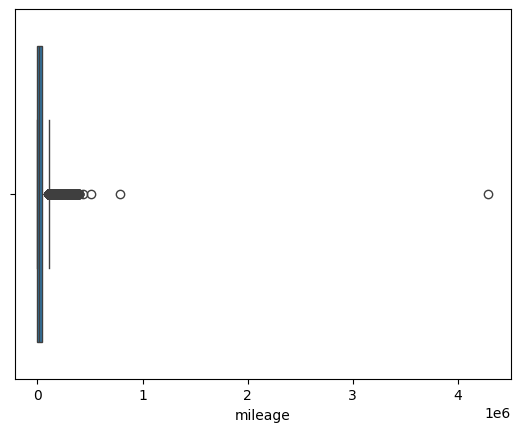

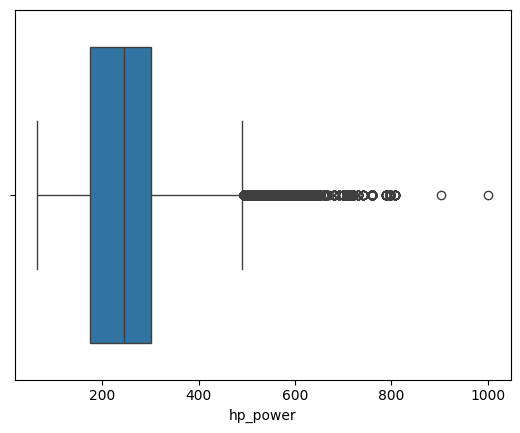

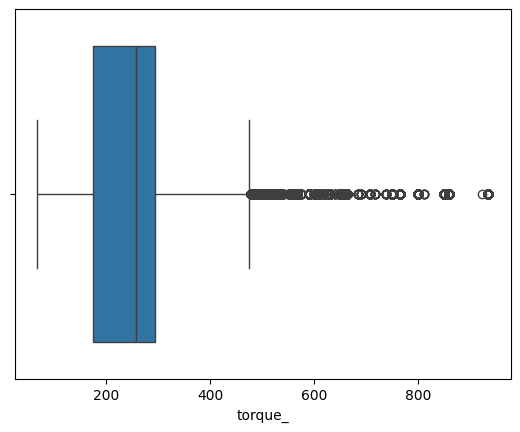

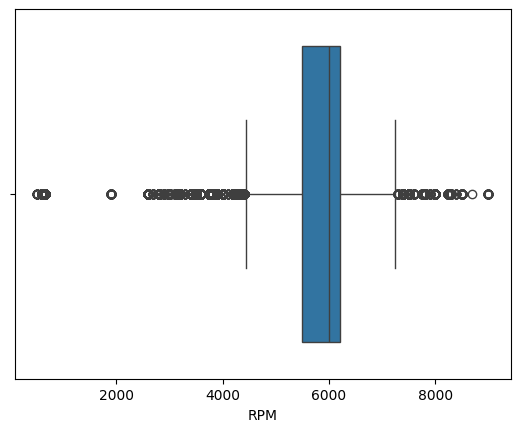

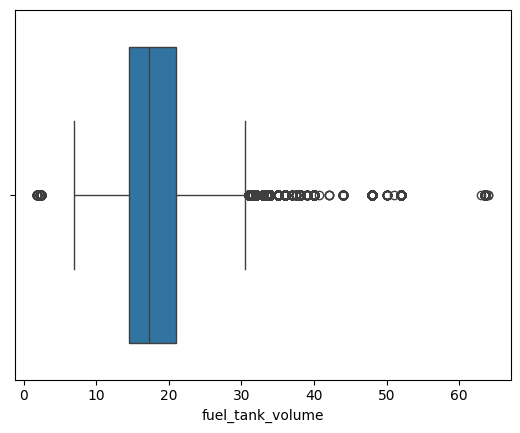

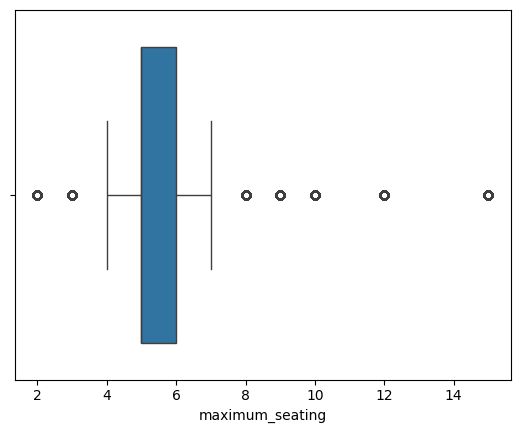

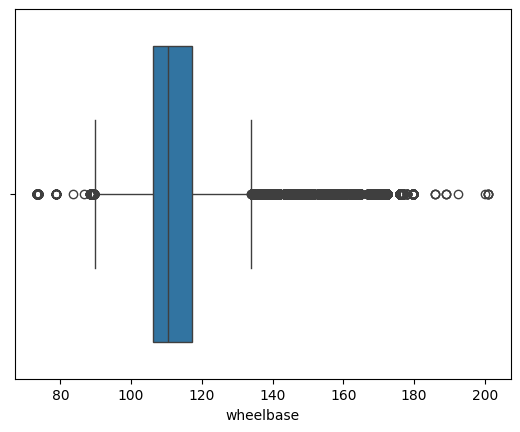

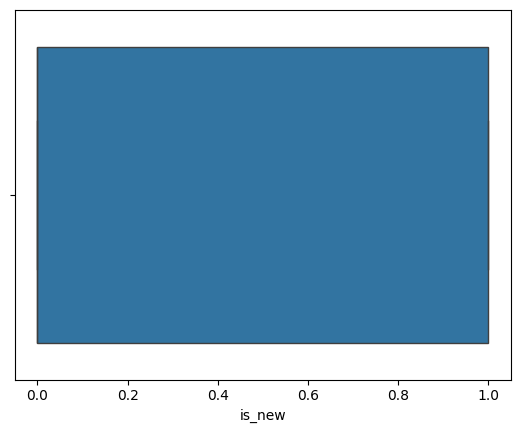

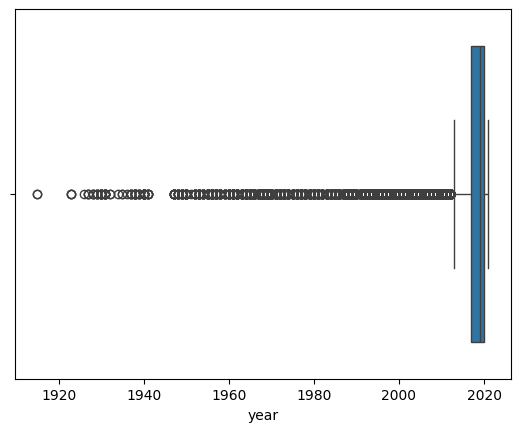

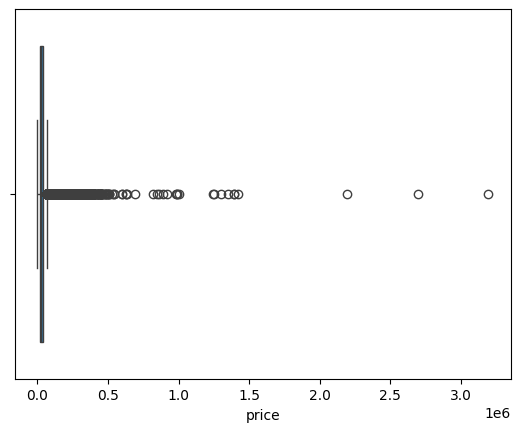

In [40]:
# Visualize outliers for every numeric column using boxplots
for i in  df.select_dtypes(include='number'):
    sns.boxplot(x=df[i])
    plt.show()

In [41]:
# Inspect rows with unusually high horsepower (>800) and take a random sample for a general look
df[df["hp_power"]>800]
df.sample(50)

,vin,model_name,engine_type,mileage,hp_power,torque_,RPM,fuel_type,fuel_tank_volume,maximum_seating,transmission,wheel_system,wheel_system_display,wheelbase,body_type,is_new,year,price
935033,YV4102RL4M1695173,XC60,I4,NaN,250.0,258.0,5500.0,Gasoline,18.8,5.0,A,AWD,All-Wheel Drive,112.8,SUV / Crossover,1.0,2021,56175.0
106695,1N4BA41E86C857316,Maxima,V6,171461.0,265.0,255.0,5800.0,Gasoline,20.0,5.0,A,FWD,Front-Wheel Drive,111.2,Sedan,0.0,2006,2990.0
423389,1C4BJWDG2HL649714,Wrangler Unlimited,V6,32187.0,285.0,260.0,6400.0,Gasoline,22.5,5.0,A,4WD,Four-Wheel Drive,116.0,SUV / Crossover,0.0,2017,31988.0
233440,3N1AB7AP7GL662211,Sentra,I4,100118.0,130.0,NaN,6000.0,Gasoline,13.2,5.0,CVT,FWD,Front-Wheel Drive,106.3,Sedan,0.0,2016,9390.0
429297,1C4RDJDG3HC611398,Durango,V6,73531.0,295.0,260.0,6400.0,Gasoline,24.6,7.0,A,AWD,All-Wheel Drive,119.8,SUV / Crossover,0.0,2017,27708.0
54807,1FMCU9GX2GUB65491,Escape,I4,27561.0,240.0,270.0,5500.0,Gasoline,15.1,5.0,A,AWD,All-Wheel Drive,105.9,SUV / Crossover,0.0,2016,14740.0
187569,5NPEU46F37H276683,Sonata,V6,157438.0,234.0,226.0,6000.0,Gasoline,17.7,5.0,A,FWD,Front-Wheel Drive,107.4,Sedan,0.0,2007,3999.0
675513,4T1BK46KX8U061939,Camry,V6,210664.0,268.0,248.0,6200.0,Gasoline,18.5,5.0,A,FWD,Front-Wheel Drive,109.3,Sedan,0.0,2008,4877.0
223307,1FM5K7D81HGD97774,Explorer,V6,37918.0,290.0,255.0,6500.0,Gasoline,18.6,7.0,A,FWD,Front-Wheel Drive,112.8,SUV / Crossover,0.0,2017,26920.0
753317,YV4A22RL1M1688840,XC60,I4,6.0,316.0,295.0,5700.0,Gasoline,18.8,5.0,A,AWD,All-Wheel Drive,112.8,SUV / Crossover,1.0,2021,57190.0


In [42]:
# Helper function to compute IQR-based lower/upper outlier bounds for a given column
def outliers_detection(col,df=df):
    global Q1 ,LE,UE
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    LE = Q1 - (1.5*IQR)
    UE = Q3 + (1.5*IQR)
    

In [43]:
# Compute outlier bounds for the 'mileage' column
outliers_detection("mileage")

In [44]:
# View the lower bound (LE) for mileage outliers
LE

-67355.5

In [45]:
# View the upper bound (UE) for mileage outliers
UE

112272.5

In [46]:
# Fix impossible values: cap mileage for 'new' cars at a realistic amount (replace with median)
# New cars shouldn't reasonably exceed ~500 miles (dealer/delivery driving)
df.loc[(df['is_new'] == 1) & (df['mileage'] > 500), 'mileage'] = df['mileage'].median()

In [47]:
# Cap extreme (but plausible) mileage outliers at the 99.5th percentile
upper = df['mileage'].quantile(0.995)  # cap top 0.5%
df['mileage'] = df['mileage'].clip(upper=upper)

In [48]:
# Display the dataframe after mileage outlier handling
df

,vin,model_name,engine_type,mileage,hp_power,torque_,RPM,fuel_type,fuel_tank_volume,maximum_seating,transmission,wheel_system,wheel_system_display,wheelbase,body_type,is_new,year,price
0,ZACNJABB5KPJ92081,Renegade,I4,7.0,177.0,200.0,5750.0,Gasoline,12.7,5.0,A,FWD,Front-Wheel Drive,101.2,SUV / Crossover,1.0,2019,23141.0
1,SALCJ2FX1LH858117,Discovery Sport,I4,8.0,246.0,269.0,5500.0,Gasoline,17.7,7.0,A,AWD,All-Wheel Drive,107.9,SUV / Crossover,1.0,2020,46500.0
2,JF1VA2M67G9829723,WRX STI,H4,NaN,305.0,290.0,6000.0,Gasoline,15.9,5.0,M,AWD,All-Wheel Drive,104.3,Sedan,0.0,2016,46995.0
3,SALRR2RV0L2433391,Discovery,V6,11.0,340.0,332.0,6500.0,Gasoline,23.5,7.0,A,AWD,All-Wheel Drive,115.0,SUV / Crossover,1.0,2020,67430.0
4,SALCJ2FXXLH862327,Discovery Sport,I4,7.0,246.0,269.0,5500.0,Gasoline,17.7,7.0,A,AWD,All-Wheel Drive,107.9,SUV / Crossover,1.0,2020,48880.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,5N1AZ2CSXLN153085,Murano,V6,3.0,260.0,240.0,6000.0,Gasoline,19.0,5.0,CVT,AWD,All-Wheel Drive,111.2,SUV / Crossover,1.0,2020,36267.0
999996,3KPFL4A87HE045209,Forte,I4,5037.0,164.0,151.0,6200.0,Gasoline,13.2,5.0,A,FWD,Front-Wheel Drive,106.3,Sedan,0.0,2017,15746.0
999997,KL4MMGSL1LB133763,Encore GX,I3,2.0,150.0,174.0,5600.0,Gasoline,13.2,5.0,A,4WD,Four-Wheel Drive,102.2,SUV / Crossover,1.0,2020,32222.0
999998,3N1AB8CVXLY209618,Sentra,I4,7.0,149.0,146.0,6400.0,Gasoline,12.4,5.0,CVT,FWD,Front-Wheel Drive,106.8,Sedan,1.0,2020,20479.0


In [49]:
# Compute median mileage for new cars (for reference/possible imputation)
median_new = df[df["is_new"]==1]["mileage"].median()

In [50]:
# View median mileage for new cars
median_new

5.0

In [51]:
# Compute median mileage for used cars (for reference/possible imputation)
median_old = df[df["is_new"]==0]["mileage"].median()

In [52]:
# View median mileage for used cars
median_old

41286.0

In [53]:
# Check how many mileage values are still missing
df["mileage"].isna().sum()

50631

In [54]:
# Check missing values across all columns again
df.isna().sum()

vin                          0
model_name                   0
engine_type              29170
mileage                  50631
hp_power                151057
torque_                 163211
RPM                     151057
fuel_type                24764
fuel_tank_volume         48645
maximum_seating          48319
transmission             16562
wheel_system             45553
wheel_system_display     45553
wheelbase                48296
body_type                 4369
is_new                       0
year                         0
price                        0
dtype: int64

In [55]:
# Inspect rows where hp_power is missing
df[df["hp_power"].isna()]

,vin,model_name,engine_type,mileage,hp_power,torque_,RPM,fuel_type,fuel_tank_volume,maximum_seating,transmission,wheel_system,wheel_system_display,wheelbase,body_type,is_new,year,price
50,4S3GTAA67J3747545,Impreza,NaN,19801.0,NaN,NaN,NaN,NaN,NaN,NaN,CVT,NaN,NaN,NaN,Hatchback,0.0,2018,17300.0
100,3GNAXSEV1JS586810,Equinox,I4,44244.0,NaN,NaN,NaN,Gasoline,15.6,5.0,A,4WD,Four-Wheel Drive,107.3,SUV / Crossover,0.0,2018,16924.0
106,3GNAXKEVXKS620812,Equinox,I4,4742.0,NaN,NaN,NaN,Gasoline,14.9,5.0,A,FWD,Front-Wheel Drive,107.3,SUV / Crossover,0.0,2019,20439.0
140,2GNAXHEV6K6149419,Equinox,I4,26818.0,NaN,NaN,NaN,Gasoline,14.9,5.0,A,FWD,Front-Wheel Drive,107.3,SUV / Crossover,0.0,2019,17439.0
162,WDDGF8BBXCR195380,C-Class,V6,41672.0,NaN,NaN,NaN,Gasoline,NaN,NaN,A,NaN,NaN,NaN,Sedan,0.0,2012,12500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999958,NM0GE9G23L1446554,Transit Connect,I4,0.0,NaN,NaN,NaN,Gasoline,15.8,7.0,A,FWD,Front-Wheel Drive,120.6,Van,1.0,2020,34700.0
999981,1FT7W2BT8HEE93005,F-250 Super Duty,V8 Biodiesel,30214.0,NaN,NaN,NaN,Biodiesel,34.0,6.0,A,4WD,Four-Wheel Drive,159.8,Pickup Truck,0.0,2017,50490.0
999982,1FMSK8DH6LGC88020,Explorer,I4,6.0,NaN,NaN,NaN,Gasoline,19.2,7.0,A,AWD,All-Wheel Drive,119.1,SUV / Crossover,1.0,2020,42333.0
999994,1FMCU9J99LUB40835,Escape,I4,NaN,NaN,NaN,NaN,Gasoline,15.8,5.0,A,AWD,All-Wheel Drive,106.7,SUV / Crossover,1.0,2020,40180.0


In [56]:
# Check engine_type distribution for a specific model (e.g., 'Blazer') as a reference for imputation
df[df["model_name"]=="Blazer"]["engine_type"].value_counts()

engine_type
V6           2836
I4            958
V8             11
V8 Diesel       1
Name: count, dtype: int64

In [57]:
# Drop all remaining rows that still contain any missing values
df.dropna(inplace=True)

In [58]:
# Confirm dataset info after dropping missing rows
df.info()

<class 'pandas.DataFrame'>
Index: 776023 entries, 0 to 999998
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   vin                   776023 non-null  str    
 1   model_name            776023 non-null  str    
 2   engine_type           776023 non-null  str    
 3   mileage               776023 non-null  float64
 4   hp_power              776023 non-null  float64
 5   torque_               776023 non-null  float64
 6   RPM                   776023 non-null  float64
 7   fuel_type             776023 non-null  str    
 8   fuel_tank_volume      776023 non-null  float64
 9   maximum_seating       776023 non-null  float64
 10  transmission          776023 non-null  str    
 11  wheel_system          776023 non-null  str    
 12  wheel_system_display  776023 non-null  str    
 13  wheelbase             776023 non-null  float64
 14  body_type             776023 non-null  str    
 15  is_new          

In [59]:
# Inspect rows with price above the 99th percentile (extreme high-price outliers)
df[df["price"]>df["price"].quantile(0.99)]

,vin,model_name,engine_type,mileage,hp_power,torque_,RPM,fuel_type,fuel_tank_volume,maximum_seating,transmission,wheel_system,wheel_system_display,wheelbase,body_type,is_new,year,price
9,SALZL2GX4LH007593,Range Rover Evoque,I4,254.0,296.0,295.0,5500.0,Gasoline,17.7,5.0,A,AWD,All-Wheel Drive,105.6,SUV / Crossover,0.0,2020,84399.0
10,ZARBAAC41FM129303,4C,I4,301.0,237.0,258.0,6000.0,Gasoline,10.5,2.0,A,RWD,Rear-Wheel Drive,93.7,Coupe,0.0,2015,97579.0
135,SALWS2RU4LA742754,Range Rover Sport,I6,14.0,395.0,406.0,5500.0,Gasoline,27.6,5.0,A,AWD,All-Wheel Drive,115.1,SUV / Crossover,1.0,2020,88235.0
136,SALWR2RY2LA745490,Range Rover Sport,I4,10.0,398.0,472.0,5500.0,Gasoline,24.1,5.0,A,AWD,All-Wheel Drive,115.1,SUV / Crossover,1.0,2020,90430.0
151,SALWS2RU9LA739641,Range Rover Sport,I6,18.0,395.0,406.0,5500.0,Gasoline,27.6,5.0,A,AWD,All-Wheel Drive,115.1,SUV / Crossover,1.0,2020,91355.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998615,SCBEC9ZA1GC053170,Flying Spur,W12,28988.0,616.0,590.0,6000.0,Gasoline,24.0,5.0,A,AWD,All-Wheel Drive,120.7,Sedan,0.0,2016,89786.0
998677,WP0CB2A73JL191220,Panamera,V6,8374.0,440.0,405.0,5650.0,Gasoline,23.7,4.0,A,AWD,All-Wheel Drive,116.1,Sedan,0.0,2018,85995.0
999084,1GYS4CKJ1LR149709,Escalade,V8,5.0,420.0,460.0,5600.0,Gasoline,26.0,8.0,A,4WD,Four-Wheel Drive,116.0,SUV / Crossover,1.0,2020,93025.0
999123,1GYS4CKJ4LR141006,Escalade,V8,11.0,420.0,460.0,5600.0,Gasoline,26.0,8.0,A,4WD,Four-Wheel Drive,116.0,SUV / Crossover,1.0,2020,93030.0


In [60]:
# Keep a backup reference of the cleaned dataframe
df1=df

In [61]:
# Save the cleaned dataset to CSV for use in the preprocessing/modeling stage
df.to_csv("clean_data_for_Cars01.csv",index=False)

## Data Preprocessing 

In [62]:
# Reload the cleaned dataset from CSV (starting point for preprocessing stage)
df1 = pd.read_csv(r"D:\Inno Batch 485\Machine Learning\ML Projects\Used Car  Price Prediction\Notebook\clean_data_for_Cars01.csv")

In [63]:
# Work on a copy of the cleaned data to avoid mutating the original reference
df=df1.copy()

In [64]:
# Preview the cleaned dataframe
df.head(3)

,vin,model_name,engine_type,mileage,hp_power,torque_,RPM,fuel_type,fuel_tank_volume,maximum_seating,transmission,wheel_system,wheel_system_display,wheelbase,body_type,is_new,year,price
0,ZACNJABB5KPJ92081,Renegade,I4,7.0,177.0,200.0,5750.0,Gasoline,12.7,5.0,A,FWD,Front-Wheel Drive,101.2,SUV / Crossover,1.0,2019,23141.0
1,SALCJ2FX1LH858117,Discovery Sport,I4,8.0,246.0,269.0,5500.0,Gasoline,17.7,7.0,A,AWD,All-Wheel Drive,107.9,SUV / Crossover,1.0,2020,46500.0
2,SALRR2RV0L2433391,Discovery,V6,11.0,340.0,332.0,6500.0,Gasoline,23.5,7.0,A,AWD,All-Wheel Drive,115.0,SUV / Crossover,1.0,2020,67430.0


In [65]:
# Check dtypes and non-null counts of the cleaned dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 776023 entries, 0 to 776022
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   vin                   776023 non-null  str    
 1   model_name            776023 non-null  str    
 2   engine_type           776023 non-null  str    
 3   mileage               776023 non-null  float64
 4   hp_power              776023 non-null  float64
 5   torque_               776023 non-null  float64
 6   RPM                   776023 non-null  float64
 7   fuel_type             776023 non-null  str    
 8   fuel_tank_volume      776023 non-null  float64
 9   maximum_seating       776023 non-null  float64
 10  transmission          776023 non-null  str    
 11  wheel_system          776023 non-null  str    
 12  wheel_system_display  776023 non-null  str    
 13  wheelbase             776023 non-null  float64
 14  body_type             776023 non-null  str    
 15  is_new     

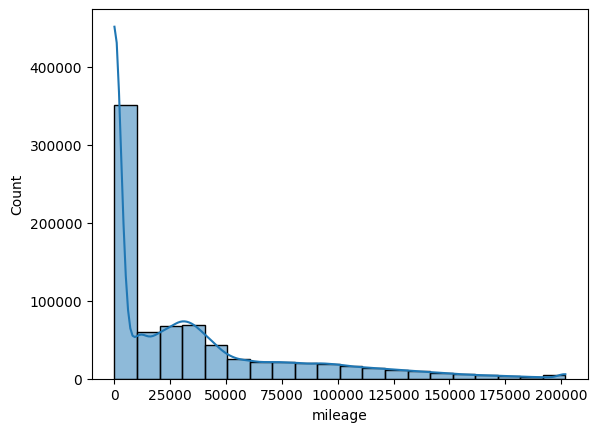

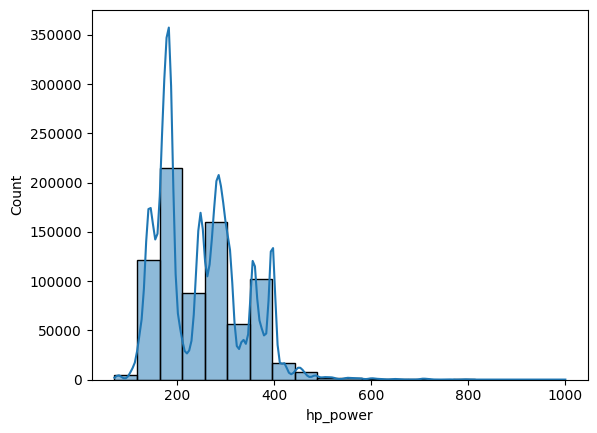

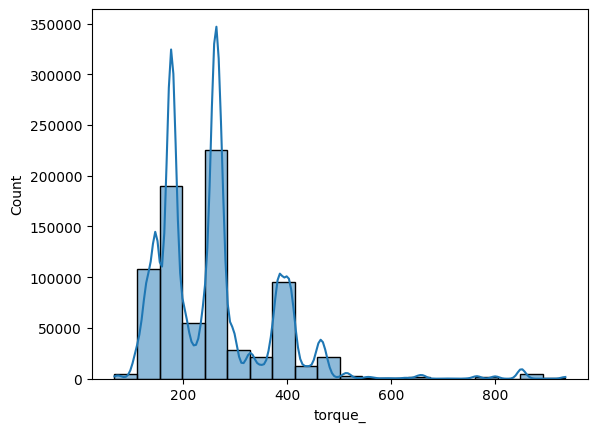

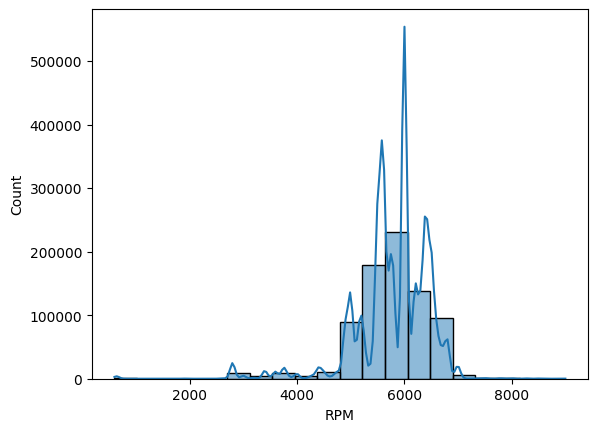

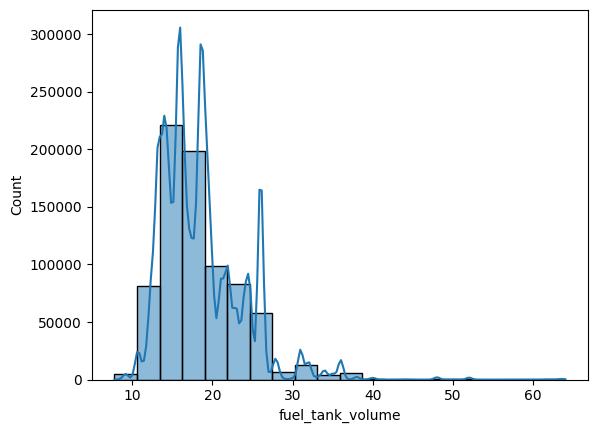

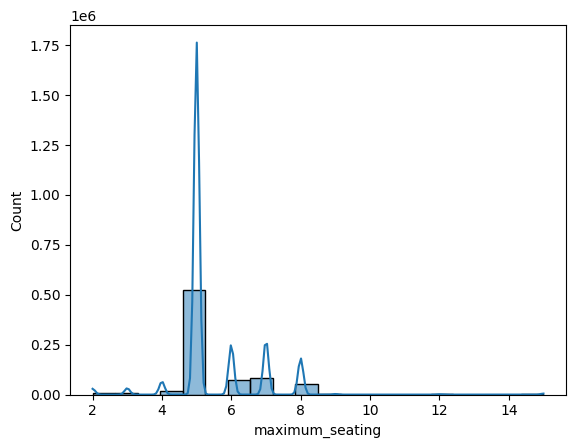

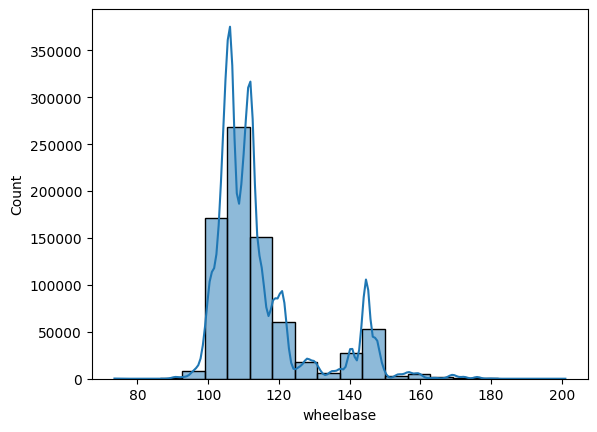

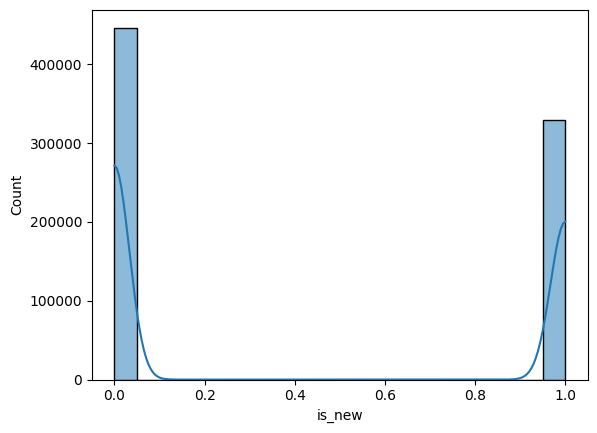

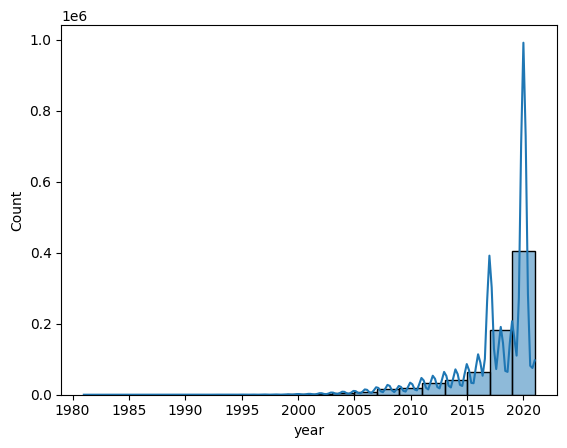

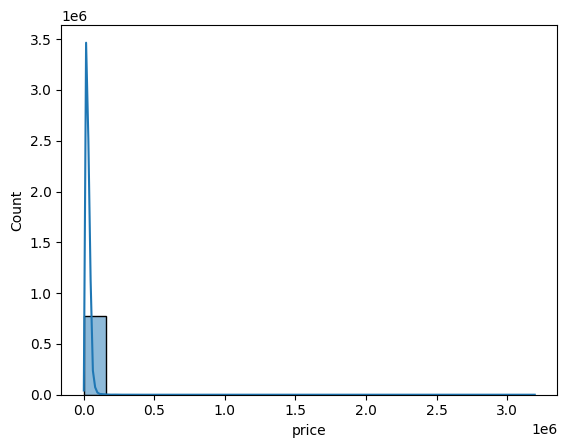

In [66]:
# Plot distribution (histogram + KDE) for every numeric column to check skewness
for i in df.select_dtypes(include='number'):
    sns.histplot(df[i],kde=True , bins=20)
    plt.show()

In [88]:
# Drop 'wheel_system_display' since it duplicates the information in 'wheel_system'
df.drop(columns=["wheel_system_display"],inplace=True) 


KeyError: "['wheel_system_display'] not found in axis"

In [ ]:
# Drop 'vin' since it's a unique identifier with no predictive value
df.drop(columns=["vin"],inplace=True) 

### Encoding with Categorical Data

In [89]:
# Label-encode all categorical columns except 'model_name' (handled separately via target encoding)
for col in  df.select_dtypes(include='object'):
    if col == "model_name":
        continue 
    else:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
       

C:\Users\dp431\AppData\Local\Temp\ipykernel_3024\171029723.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in  df.select_dtypes(include='object'):


In [90]:
# Preview dataframe after label encoding
df.head()


,model_name,engine_type,mileage,hp_power,torque_,RPM,fuel_type,fuel_tank_volume,maximum_seating,transmission,...,is_new,year,price,mileage_log,torque__log,RPM_log,hp_power_log,fuel_tank_volume_log,wheelbase_log,year_log
0,Renegade,4,7.0,177.0,200.0,5750.0,4,12.7,5.0,0,...,1.0,2019,23141.0,2.079442,5.303305,8.657129,5.181784,2.617396,4.626932,7.610853
1,Discovery Sport,4,8.0,246.0,269.0,5500.0,4,17.7,7.0,0,...,1.0,2020,46500.0,2.197225,5.598422,8.612685,5.509388,2.928524,4.690430,7.611348
2,Discovery,19,11.0,340.0,332.0,6500.0,4,23.5,7.0,0,...,1.0,2020,67430.0,2.484907,5.808142,8.779711,5.831882,3.198673,4.753590,7.611348
3,Discovery Sport,4,7.0,246.0,269.0,5500.0,4,17.7,7.0,0,...,1.0,2020,48880.0,2.079442,5.598422,8.612685,5.509388,2.928524,4.690430,7.611348
4,Range Rover Velar,4,12.0,247.0,269.0,5500.0,4,16.6,5.0,0,...,1.0,2020,66903.0,2.564949,5.598422,8.612685,5.513429,2.867899,4.737075,7.611348


In [91]:
# Apply log1p transformation to right-skewed numerical columns to reduce skewness
skewed_cols = ["mileage", 'torque_',"RPM","hp_power",'fuel_tank_volume', 'wheelbase',"year"]
for c in skewed_cols:
    df[c + '_log'] = np.log1p(df[c])

In [92]:
# Display dataframe after log transformation
df.head(2)

,model_name,engine_type,mileage,hp_power,torque_,RPM,fuel_type,fuel_tank_volume,maximum_seating,transmission,...,is_new,year,price,mileage_log,torque__log,RPM_log,hp_power_log,fuel_tank_volume_log,wheelbase_log,year_log
0,Renegade,4,7.0,177.0,200.0,5750.0,4,12.7,5.0,0,...,1.0,2019,23141.0,2.079442,5.303305,8.657129,5.181784,2.617396,4.626932,7.610853
1,Discovery Sport,4,8.0,246.0,269.0,5500.0,4,17.7,7.0,0,...,1.0,2020,46500.0,2.197225,5.598422,8.612685,5.509388,2.928524,4.690430,7.611348


In [93]:
# Define the feature set (X) to be used for model training
X= df[[ "model_name","engine_type", "fuel_type", "fuel_tank_volume", "maximum_seating", "transmission", "wheel_system", "body_type", "is_new","mileage_log", "torque__log","RPM_log","hp_power_log", "fuel_tank_volume_log", "wheelbase_log","year_log"]]

In [94]:
# Display the feature set X
X

,model_name,engine_type,fuel_type,fuel_tank_volume,maximum_seating,transmission,wheel_system,body_type,is_new,mileage_log,torque__log,RPM_log,hp_power_log,fuel_tank_volume_log,wheelbase_log,year_log
0,Renegade,4,4,12.7,5.0,0,3,5,1.0,2.079442,5.303305,8.657129,5.181784,2.617396,4.626932,7.610853
1,Discovery Sport,4,4,17.7,7.0,0,2,5,1.0,2.197225,5.598422,8.612685,5.509388,2.928524,4.690430,7.611348
2,Discovery,19,4,23.5,7.0,0,2,5,1.0,2.484907,5.808142,8.779711,5.831882,3.198673,4.753590,7.611348
3,Discovery Sport,4,4,17.7,7.0,0,2,5,1.0,2.079442,5.598422,8.612685,5.509388,2.928524,4.690430,7.611348
4,Range Rover Velar,4,4,16.6,5.0,0,2,5,1.0,2.564949,5.598422,8.612685,5.513429,2.867899,4.737075,7.611348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
776018,Rogue,4,4,14.5,5.0,1,2,5,1.0,1.386294,5.170484,8.699681,5.141664,2.740840,4.677491,7.611348
776019,Murano,19,4,19.0,5.0,1,2,5,1.0,1.386294,5.484797,8.699681,5.564520,2.995732,4.720283,7.611348
776020,Forte,4,4,13.2,5.0,0,3,6,0.0,8.524764,5.023881,8.732466,5.105945,2.653242,4.675629,7.609862
776021,Encore GX,3,4,13.2,5.0,0,0,5,1.0,1.098612,5.164786,8.630700,5.017280,2.653242,4.636669,7.611348


In [95]:
# Define the target variable (y) — the price we want to predict
y=df["price"]

In [96]:
# Display the target variable y
y

0         23141.0
1         46500.0
2         67430.0
3         48880.0
4         66903.0
           ...   
776018    25832.0
776019    36267.0
776020    15746.0
776021    32222.0
776022    20479.0
Name: price, Length: 776023, dtype: float64

### Split Data into Train and Test set 

In [97]:
# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test =  train_test_split( X, y, test_size=0.2, random_state=42)

In [98]:
# Drop the raw fuel_tank_volume column since we already have its log-transformed version (avoid duplicate/multicollinear feature)
X_train = X_train.drop(columns=['fuel_tank_volume'])
X_test = X_test.drop(columns=['fuel_tank_volume'])

In [99]:
# Preview X_train after dropping fuel_tank_volume
X_train.head()

,model_name,engine_type,fuel_type,maximum_seating,transmission,wheel_system,body_type,is_new,mileage_log,torque__log,RPM_log,hp_power_log,fuel_tank_volume_log,wheelbase_log,year_log
605819,Frontier,19,4,5.0,0,0,4,0.0,10.358948,5.641907,8.630700,5.568345,3.095578,4.843399,7.610853
727260,Cooper,3,4,5.0,0,3,2,0.0,11.502299,5.093750,8.412055,4.905275,2.533697,4.625953,7.608871
318137,XT5,19,4,5.0,0,0,5,0.0,8.388223,5.605802,8.810012,5.739793,3.122365,4.731803,7.610853
244875,F-150,19,4,6.0,0,0,4,1.0,9.302555,5.993961,8.657129,5.981414,3.295837,4.983607,7.611348
751921,Sierra 3500HD,27,2,5.0,0,0,4,0.0,10.503971,6.641182,8.006701,5.986452,3.610918,5.041488,7.607381


In [100]:
# Preview X_test after dropping fuel_tank_volume
X_test.head()

,model_name,engine_type,fuel_type,maximum_seating,transmission,wheel_system,body_type,is_new,mileage_log,torque__log,RPM_log,hp_power_log,fuel_tank_volume_log,wheelbase_log,year_log
327736,Civic,4,4,5.0,0,3,6,0.0,11.868255,4.859812,8.748464,4.948760,2.653242,4.675629,7.605392
446996,Escape,4,4,5.0,0,2,5,1.0,2.079442,5.620401,8.612685,5.505332,2.815409,4.671894,7.610853
745603,Acadia,19,4,7.0,0,0,5,1.0,0.000000,5.605802,8.810012,5.739793,3.135494,4.731803,7.611348
743141,Mirage G4,3,4,5.0,0,3,6,1.0,2.564949,4.317488,8.699681,4.369448,2.322388,4.619073,7.611348
470579,Equinox,4,4,5.0,0,3,5,1.0,0.000000,5.318120,8.630700,5.141664,2.766319,4.684905,7.611348


In [101]:
# Leak-safe target encoding for model_name: compute mean price per model using TRAIN data only,
# map it onto both train and test, fill unseen categories with the global mean, then drop the raw text column
train_temp = X_train.copy()
train_temp['price'] = y_train

model_price_map = train_temp.groupby('model_name')['price'].mean()

# Apply the mapping to both train and test
X_train['model_name_encoded'] = X_train['model_name'].map(model_price_map)
X_test['model_name_encoded'] = X_test['model_name'].map(model_price_map)

# Handle model_names in test that never appeared in train (map gives NaN)
global_mean_price = y_train.mean()
X_test['model_name_encoded'] = X_test['model_name_encoded'].fillna(global_mean_price)

# Drop the original text column now that we have the encoded version
X_train = X_train.drop(columns=['model_name'])
X_test = X_test.drop(columns=['model_name'])

print(X_train[['model_name_encoded']].describe())
print('Unseen categories in test:', X_test['model_name_encoded'].isna().sum())

       model_name_encoded
count        6.208180e+05
mean         2.850148e+04
std          1.472331e+04
min          9.950000e+02
25%          2.024321e+04
50%          2.524709e+04
75%          3.514742e+04
max          3.195000e+06
Unseen categories in test: 0


## Scaling

In [102]:
# Initialize a MinMaxScaler to scale numerical features into the [0, 1] range
scaler = MinMaxScaler()

In [103]:
# Check shape and dtypes of X_train before scaling
print(X_train.shape)
print(X_train.info())

(620818, 15)
<class 'pandas.DataFrame'>
Index: 620818 entries, 605819 to 121958
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   engine_type           620818 non-null  int32  
 1   fuel_type             620818 non-null  int32  
 2   maximum_seating       620818 non-null  float64
 3   transmission          620818 non-null  int32  
 4   wheel_system          620818 non-null  int32  
 5   body_type             620818 non-null  int32  
 6   is_new                620818 non-null  float64
 7   mileage_log           620818 non-null  float64
 8   torque__log           620818 non-null  float64
 9   RPM_log               620818 non-null  float64
 10  hp_power_log          620818 non-null  float64
 11  fuel_tank_volume_log  620818 non-null  float64
 12  wheelbase_log         620818 non-null  float64
 13  year_log              620818 non-null  float64
 14  model_name_encoded    620818 non-null  float64
dty

In [104]:
# Fit the scaler on training data only, then transform both train and test (avoids data leakage)
X_train_trans= scaler.fit_transform(X_train)
X_test_trans= scaler.transform(X_test)

In [105]:
# Rebuild X_train/X_test as DataFrames with original column names after scaling
X_train = pd.DataFrame(X_train_trans,columns=X_train.columns)
X_test  = pd.DataFrame(X_test_trans,columns=X_train.columns)

In [106]:
# Preview scaled X_train
X_train.head()

,engine_type,fuel_type,maximum_seating,transmission,wheel_system,body_type,is_new,mileage_log,torque__log,RPM_log,hp_power_log,fuel_tank_volume_log,wheelbase_log,year_log,model_name_encoded
0,0.575758,0.8,0.230769,0.0,0.00,0.500,0.0,0.847994,0.539902,0.824722,0.513203,0.460497,0.568881,0.950472,0.005960
1,0.090909,0.8,0.230769,0.0,0.75,0.250,0.0,0.941590,0.329680,0.743936,0.252577,0.179505,0.336622,0.851268,0.005622
2,0.575758,0.8,0.230769,0.0,0.00,0.625,0.0,0.686669,0.526056,0.890974,0.580592,0.473893,0.449682,0.950472,0.012708
3,0.575758,0.8,0.307692,0.0,0.00,0.500,1.0,0.761517,0.674918,0.834486,0.675563,0.560645,0.718639,0.975242,0.012593
4,0.818182,0.4,0.230769,0.0,0.00,0.500,0.0,0.859866,0.923132,0.594165,0.677544,0.718214,0.780463,0.776736,0.012800


In [107]:
# Downcast to float32 to reduce memory usage during model training
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# Data Visualization

In [108]:
print(y_train.shape)
print(X_train.shape)

(620818,)
(620818, 15)


In [109]:
df=pd.concat((X_train,y_train),axis=1)
df.shape

(744958, 16)

In [110]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

df = pd.concat((X_train, y_train), axis=1)
print(df.shape)  

(620818, 16)


In [111]:
df

,engine_type,fuel_type,maximum_seating,transmission,wheel_system,body_type,is_new,mileage_log,torque__log,RPM_log,hp_power_log,fuel_tank_volume_log,wheelbase_log,year_log,model_name_encoded,price
0,0.575758,0.8,0.230769,0.0,0.00,0.500,0.0,0.847994,0.539903,0.824722,0.513203,0.460497,0.568881,0.950472,0.005960,29489.0
1,0.090909,0.8,0.230769,0.0,0.75,0.250,0.0,0.941590,0.329680,0.743936,0.252577,0.179505,0.336622,0.851268,0.005622,14495.0
2,0.575758,0.8,0.230769,0.0,0.00,0.625,0.0,0.686669,0.526056,0.890974,0.580592,0.473893,0.449682,0.950472,0.012708,53040.0
3,0.575758,0.8,0.307692,0.0,0.00,0.500,1.0,0.761517,0.674918,0.834486,0.675563,0.560645,0.718639,0.975242,0.012593,51110.0
4,0.818182,0.4,0.230769,0.0,0.00,0.500,0.0,0.859866,0.923132,0.594165,0.677544,0.718214,0.780463,0.776736,0.012800,43900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620813,0.121212,0.8,0.230769,0.0,0.75,0.750,1.0,0.159294,0.251674,0.862322,0.288714,0.266698,0.389681,0.975242,0.004771,18469.0
620814,0.121212,0.8,0.230769,0.0,0.50,0.625,1.0,0.305969,0.423175,0.782857,0.386905,0.332224,0.377669,0.975242,0.007981,40445.0
620815,0.121212,0.8,0.230769,0.0,0.75,0.750,1.0,0.131750,0.251674,0.862322,0.288714,0.266698,0.389681,0.975242,0.004771,20085.0
620816,0.575758,0.8,0.076923,0.0,0.75,0.875,1.0,0.209969,0.510224,0.874051,0.540721,0.522157,0.650679,0.975242,0.010441,32211.0


<Axes: xlabel='mileage_log', ylabel='price'>

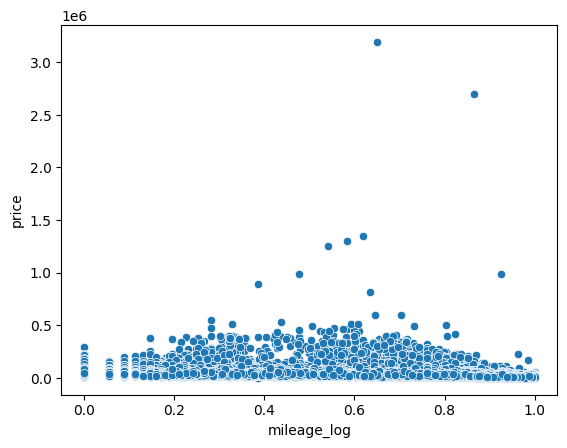

In [112]:
sns.scatterplot(x="mileage_log",y="price",data=df)

<Axes: xlabel='RPM_log', ylabel='price'>

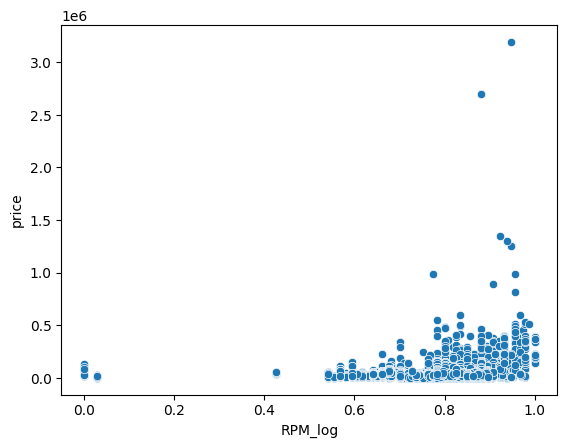

In [113]:
sns.scatterplot(x="RPM_log",y="price",data=df)

<Axes: xlabel='torque__log', ylabel='price'>

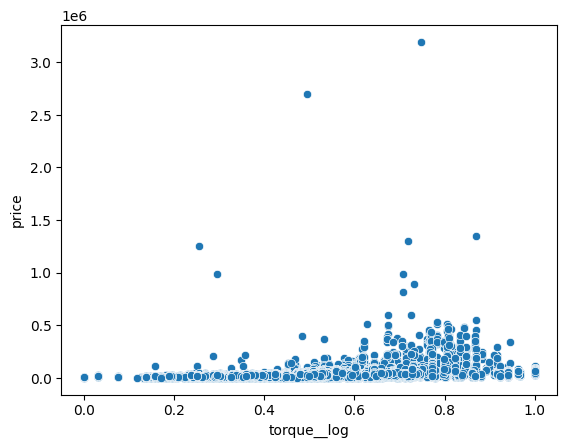

In [114]:
sns.scatterplot(x="torque__log",y="price",data=df)

<Axes: xlabel='RPM_log', ylabel='price'>

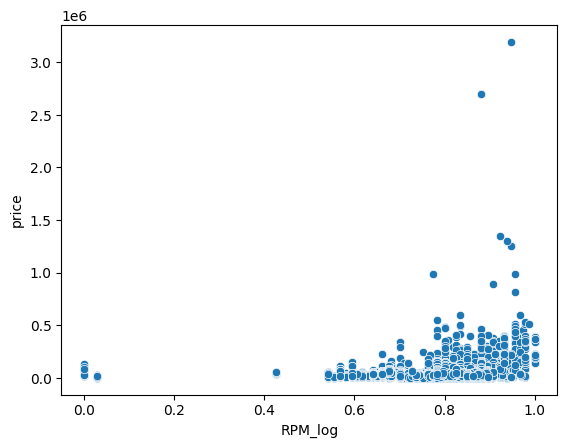

In [115]:
sns.scatterplot(x="RPM_log",y="price",data=df)

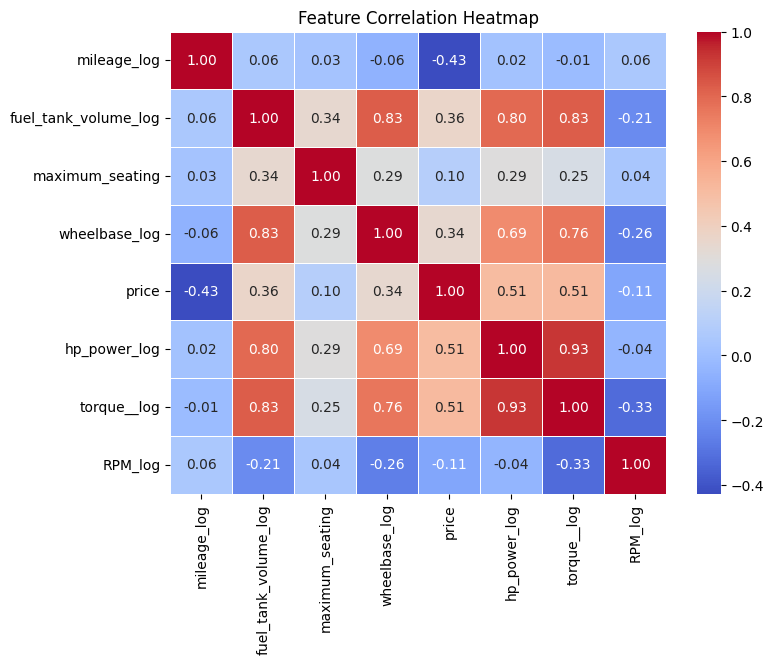

In [119]:
cols=df[["mileage_log","fuel_tank_volume_log","maximum_seating","wheelbase_log","price","hp_power_log","torque__log","RPM_log"]]
plt.figure(figsize=(8, 6))
sns.heatmap(cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [117]:
X_train.to_csv("X_train.csv",index=False)
X_test.to_csv("X_test.csv",index=False)
y_train.to_csv("y_train.csv",index=False)
y_test.to_csv("y_test.csv",index=False)

In [ ]:
#  For Further Process please go at Module Building file 